In [1]:
import pandas as pd
import seaborn as sns
import pandas_datareader.data as pdr
from datetime import datetime
import yfinance as yf

In [2]:
df = yf.download("TSLA", start="2020-01-01")

# Remove the Ticker level
df.columns = df.columns.get_level_values(0)

# Rename to lowercase
df.columns = df.columns.str.lower()

print(df.head())

[*********************100%***********************]  1 of 1 completed

Price           close       high        low       open     volume
Date                                                             
2020-01-02  28.684000  28.713333  28.114000  28.299999  142981500
2020-01-03  29.534000  30.266666  29.128000  29.366667  266677500
2020-01-06  30.102667  30.104000  29.333332  29.364668  151995000
2020-01-07  31.270666  31.441999  30.224001  30.760000  268231500
2020-01-08  32.809334  33.232666  31.215334  31.580000  467164500


In [4]:
df.sample(5)

Price,close,high,low,open,volume
Date,,,,,
2025-05-30,346.459991,363.679993,345.290009,355.519989,123474900
2025-02-28,292.980011,293.880005,273.600006,279.500000,115697000
2022-12-02,194.860001,196.250000,191.110001,191.779999,73645900
2026-01-14,439.200012,443.910004,434.220001,442.809998,57259500
2024-09-09,216.270004,219.869995,213.669998,216.199997,67443500


In [5]:
import matplotlib.pyplot as plt

<Axes: xlabel='Date'>

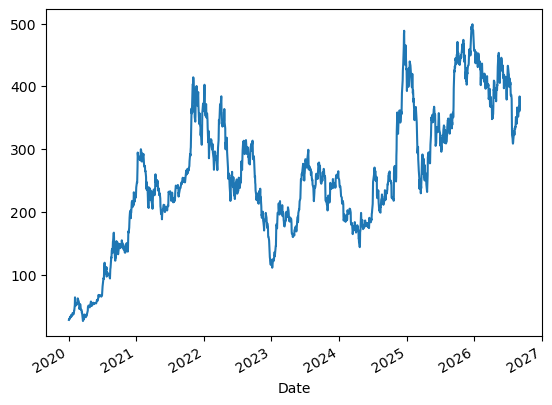

In [8]:
df['high'].plot()

<Axes: xlabel='Date'>

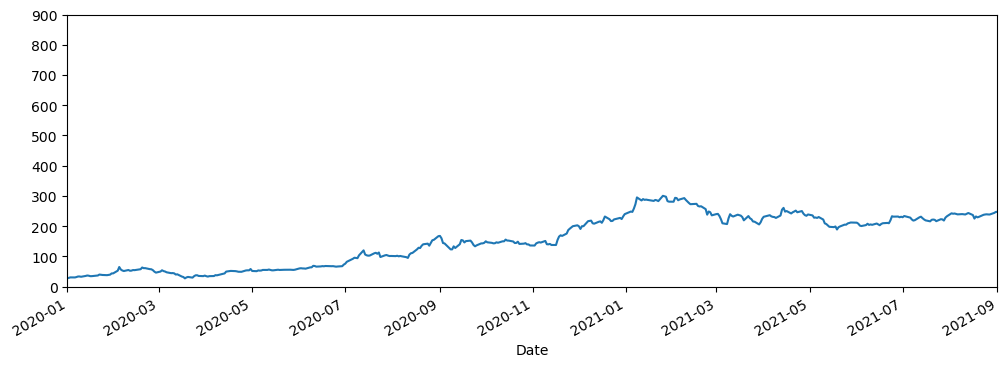

In [10]:
## xlimit and y limit
df['high'].plot(xlim=['2020-01-01','2021-09-01'],ylim=[0,900],figsize=(12,4))

<Axes: xlabel='Date'>

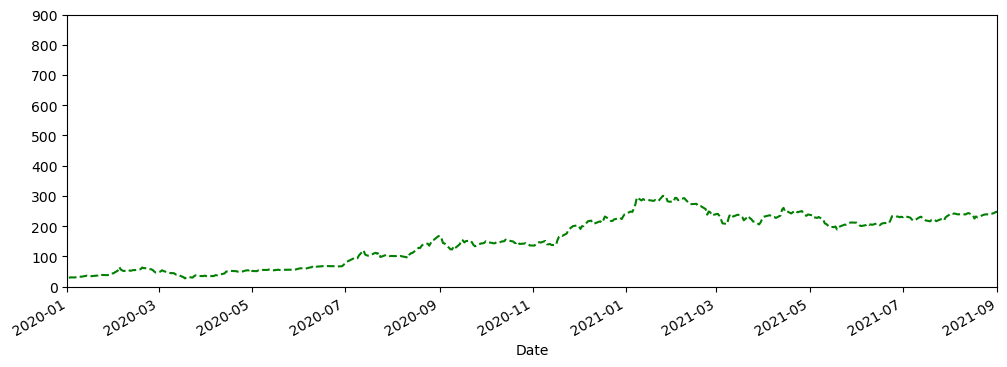

In [19]:
df['high'].plot(xlim=['2020-01-01','2021-09-01'],ylim=[0,900],figsize=(12,4),ls='--',c='green')

In [20]:
df.index

DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2026-08-24', '2026-08-25', '2026-08-26', '2026-08-27',
               '2026-08-28', '2026-08-31', '2026-09-01', '2026-09-02',
               '2026-09-03', '2026-09-04'],
              dtype='datetime64[ns]', name='Date', length=1678, freq=None)

In [24]:
df.loc['2020-01-01':'2021-09-01'].index


DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2021-08-19', '2021-08-20', '2021-08-23', '2021-08-24',
               '2021-08-25', '2021-08-26', '2021-08-27', '2021-08-30',
               '2021-08-31', '2021-09-01'],
              dtype='datetime64[ns]', name='Date', length=421, freq=None)

In [28]:
index=df.loc['2020-01-01':'2021-09-01'].index
share_open=df.loc['2020-01-01':'2021-09-01']['open']

In [29]:
share_open

Date
2020-01-02     28.299999
2020-01-03     29.366667
2020-01-06     29.364668
2020-01-07     30.760000
2020-01-08     31.580000
                 ...    
2021-08-26    236.103333
2021-08-27    235.000000
2021-08-30    238.240005
2021-08-31    244.333328
2021-09-01    244.693329
Name: open, Length: 421, dtype: float64

In [30]:
index

DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2021-08-19', '2021-08-20', '2021-08-23', '2021-08-24',
               '2021-08-25', '2021-08-26', '2021-08-27', '2021-08-30',
               '2021-08-31', '2021-09-01'],
              dtype='datetime64[ns]', name='Date', length=421, freq=None)

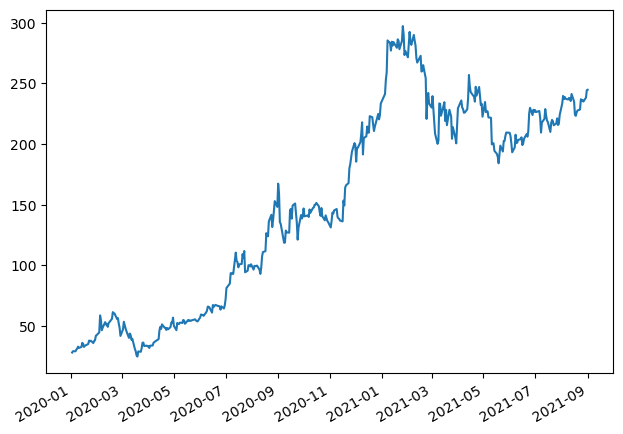

In [32]:
figure,axis=plt.subplots()
plt.tight_layout()
## Preventing overlapping
figure.autofmt_xdate()
axis.plot(index,share_open)

In [33]:
## Datetime Index

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1678 entries, 2020-01-02 to 2026-09-04
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   close   1678 non-null   float64
 1   high    1678 non-null   float64
 2   low     1678 non-null   float64
 3   open    1678 non-null   float64
 4   volume  1678 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 143.2 KB


In [36]:
df = df.reset_index()

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1678 entries, 0 to 1677
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1678 non-null   datetime64[ns]
 1   close   1678 non-null   float64       
 2   high    1678 non-null   float64       
 3   low     1678 non-null   float64       
 4   open    1678 non-null   float64       
 5   volume  1678 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 78.8 KB


In [38]:
df = df.set_index('Date',drop=True)

In [39]:
df.sample(5)

Price,close,high,low,open,volume
Date,,,,,
2021-04-23,243.133331,245.786667,238.486664,239.933334,85110000
2023-03-24,190.410004,192.360001,187.149994,191.649994,116312400
2025-12-12,458.959991,463.010010,441.670013,448.089996,95656700
2020-09-04,139.440002,142.666672,124.006668,134.270004,330965700
2025-03-06,263.450012,272.649994,260.019989,272.059998,98451600


In [40]:
## datetime
from datetime import datetime

In [41]:
datetime(2011,11,21)

datetime.datetime(2011, 11, 21, 0, 0)

In [42]:
datetime.now()

datetime.datetime(2026, 9, 7, 6, 42, 16, 146595)

In [43]:
date = datetime(2021,11,21)

In [44]:
date

datetime.datetime(2021, 11, 21, 0, 0)

In [46]:
date.date()

datetime.date(2021, 11, 21)

In [47]:
date.day

21

In [48]:
date.month

11

In [49]:
date.weekday()

6

In [50]:
date.year

2021

In [51]:
# Time Resampling

In [52]:
df.head()

Price,close,high,low,open,volume
Date,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500


In [55]:
df.resample(rule='YE').min()

Price,close,high,low,open,volume
Date,,,,,
2020-12-31,24.081333,26.990667,23.367332,24.980000,52073100
2021-12-31,187.666672,188.736664,179.830002,184.183334,29401800
2022-12-31,109.099998,116.269997,108.239998,110.349998,41864700
2023-12-31,108.099998,111.750000,101.809998,103.000000,65125200
2024-12-31,142.050003,144.440002,138.800003,140.559998,37167600
2025-12-31,221.860001,230.100006,214.250000,223.779999,36252900
2026-12-31,298.320007,309.059998,297.380005,302.700012,23345200


In [57]:
df.resample(rule='YE').max()

Price,close,high,low,open,volume
Date,,,,,
2020-12-31,235.223328,239.573334,230.373337,233.330002,914082000
2021-12-31,409.970001,414.496674,405.666656,411.470001,268189500
2022-12-31,399.926666,402.666656,378.679993,396.516663,221923300
2023-12-31,293.339996,299.290009,289.519989,296.040009,306590600
2024-12-31,479.859985,488.540009,457.510010,475.899994,243869700
2025-12-31,489.880005,498.829987,485.329987,489.880005,287499800
2026-12-31,451.670013,458.339996,444.570007,457.799988,115606400


<Axes: xlabel='Date'>

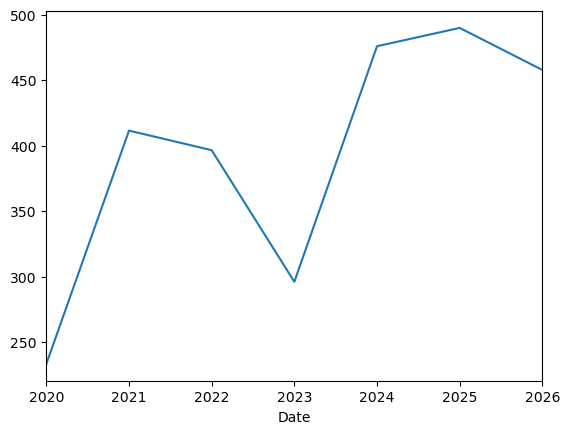

In [58]:
##year end frequency
df.resample(rule='YE').max()['open'].plot()

In [60]:
df['open:30 days rolling']=df['open'].rolling(30).mean()

In [63]:
df.head(35)

Price,close,high,low,open,volume,open:30 days rolling
Date,,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500,NaN
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500,NaN
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000,NaN
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500,NaN
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500,NaN
2020-01-09,32.089333,33.253334,31.524668,33.139999,426606000,NaN
2020-01-10,31.876667,32.329334,31.580000,32.119331,194392500,NaN
2020-01-13,34.990665,35.042000,32.799999,32.900002,397764000,NaN
2020-01-14,35.861332,36.493999,34.993332,36.284000,434943000,NaN


<Axes: xlabel='Date'>

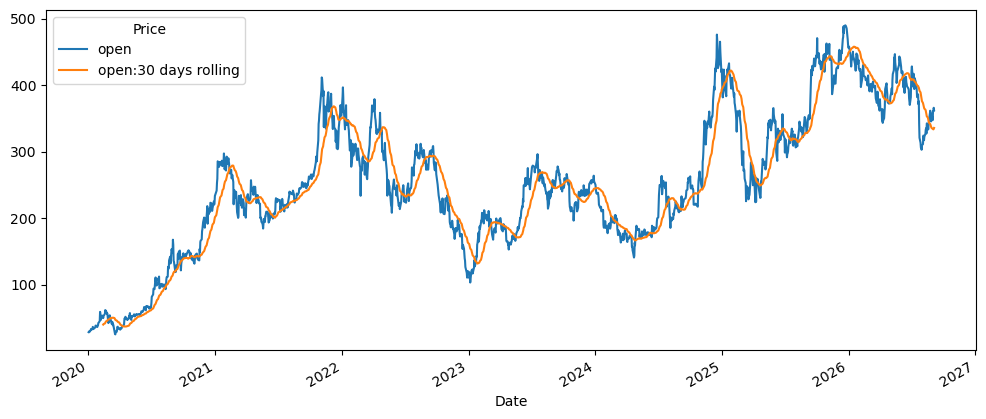

In [64]:
df[['open','open:30 days rolling']].plot(figsize=(12,5))